# TinyStories Llama-Tokenizer Next-Token Analysis

This notebook replaces the earlier character-level inspection with a token-level setup using the local Llama tokenizer.

Important caveat: the NumPy experiment uses a compact vocabulary of frequent Llama tokenizer IDs, so rare tokens are filtered out. This keeps STDP/BTSP matrices and the LSTM softmax tractable while preserving token-level next-token behavior.


In [6]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from transformers import AutoTokenizer

ROOT = Path('/private/zhenningshi/idea')
RUN_DIR = ROOT / 'output' / 'tinystories_llama_token'
CKPT = RUN_DIR / 'checkpoint.npz'
CONFIG = RUN_DIR / 'config.json'
ckpt = np.load(CKPT, allow_pickle=True)
with open(CONFIG, 'r', encoding='utf-8') as f:
    config = json.load(f)

tokenizer = AutoTokenizer.from_pretrained(config['tokenizer_dir'], local_files_only=True)
kept_raw = ckpt['kept_raw_ids'].astype(np.int64)
raw_to_compact = {int(raw): i for i, raw in enumerate(kept_raw)}
compact_to_raw = {i: int(raw) for i, raw in enumerate(kept_raw)}
vocab_size = len(kept_raw)

params = {
    'emb': ckpt['emb'],
    'wx': ckpt['wx'],
    'wh': ckpt['wh'],
    'b': ckpt['b'],
    'w_out': ckpt['w_out'],
    'b_out': ckpt['b_out'],
}
stdp_w = ckpt['stdp_weights']
btsp_w = ckpt['btsp_weights']
stdp_decay = float(ckpt['stdp_trace_decay'][0])
btsp_decay = float(ckpt['btsp_trace_decay'][0])
plastic_temp = float(ckpt['plastic_temperature'][0])
hidden_dim = params['wh'].shape[1]
print('compact vocab:', vocab_size)
print('hidden_dim:', hidden_dim)
print('metrics:')
display(pd.read_csv(RUN_DIR / 'metrics.csv'))


compact vocab: 1024
hidden_dim: 128
metrics:


,method,loss,ppl,accuracy
0,stdp_trace,5.863895,352.092708,0.132152
1,btsp_trace,5.820677,337.200255,0.084855
2,numpy_lstm,3.515212,33.623050,0.318604


In [7]:
def encode_compact(text):
    raw = tokenizer.encode(text, add_special_tokens=False)
    return np.array([raw_to_compact[t] for t in raw if t in raw_to_compact], dtype=np.int64)


def token_label(compact_id):
    raw_id = compact_to_raw[int(compact_id)]
    text = tokenizer.decode([raw_id])
    text = text.replace('\n', '\\n')
    return f'{compact_id}:{text!r}'


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -40.0, 40.0)))


def softmax(logits, temperature=1.0):
    z = logits / max(temperature, 1e-6)
    z = z - np.max(z)
    ez = np.exp(z)
    return ez / np.sum(ez)


def entropy(p):
    p = np.asarray(p, dtype=np.float64)
    return float(-np.sum(p * np.log(p + 1e-12)))


def lstm_probs(context):
    ids = encode_compact(context)
    h = np.zeros(hidden_dim, dtype=np.float32)
    c = np.zeros(hidden_dim, dtype=np.float32)
    for token in ids:
        x = params['emb'][token]
        z = params['wx'] @ x + params['wh'] @ h + params['b']
        i = sigmoid(z[:hidden_dim])
        f = sigmoid(z[hidden_dim:2*hidden_dim])
        o = sigmoid(z[2*hidden_dim:3*hidden_dim])
        g = np.tanh(z[3*hidden_dim:])
        c = f * c + i * g
        h = o * np.tanh(c)
    return softmax(params['w_out'] @ h + params['b_out'])


def plastic_probs(context, weights, decay, temperature=1.0):
    ids = encode_compact(context)
    trace = np.zeros(vocab_size, dtype=np.float32)
    for token in ids:
        trace *= decay
        trace[token] += 1.0
    return softmax(weights @ trace, temperature)


def topk(probs, k=12):
    order = np.argsort(-probs)[:k]
    return pd.DataFrame({
        'rank': np.arange(1, len(order) + 1),
        'compact_id': order,
        'token': [token_label(i) for i in order],
        'prob': [float(probs[i]) for i in order],
    })


## Same Context, Three Next-Token Distributions

Edit the contexts below. Unlike the char-level notebook, tokens are Llama tokenizer tokens, so top predictions are subwords/words/punctuation rather than characters.


In [8]:
contexts = [
    'Once upon a time',
    'Once upon a time, there was a little',
    'The little girl said',
    'She was very happy',
    'He went to the',
    'The dog ran into the',
]

for context in contexts:
    print('\nCONTEXT:', repr(context))
    print('compact ids:', encode_compact(context).tolist())
    for name, probs in [
        ('LSTM', lstm_probs(context)),
        ('STDP', plastic_probs(context, stdp_w, stdp_decay, plastic_temp)),
        ('BTSP', plastic_probs(context, btsp_w, btsp_decay, plastic_temp)),
    ]:
        print(f'  {name}: entropy={entropy(probs):.3f}, top={token_label(int(np.argmax(probs)))}, p_top={float(np.max(probs)):.3f}')
        display(topk(probs, 10))



CONTEXT: 'Once upon a time'
compact ids: [717, 463, 19, 102]
  LSTM: entropy=1.337, top=2:',', p_top=0.707


,rank,compact_id,token,prob
0,1,2,"2:','",0.707245
1,2,125,125:' there',0.137714
2,3,4,4:'.',0.033489
3,4,28,28:' to',0.015186
4,5,61,61:' he',0.010653
5,6,19,19:' a',0.008059
6,7,26,26:' in',0.008010
7,8,30,30:' and',0.007990
8,9,68,68:'.\\n',0.007681
9,10,38,38:' on',0.005925


  STDP: entropy=6.019, top=125:' there', p_top=0.114


,rank,compact_id,token,prob
0,1,125,125:' there',0.114414
1,2,102,102:' time',0.100433
2,3,291,291:' little',0.016389
3,4,269,269:' big',0.016150
4,5,2,"2:','",0.005157
5,6,374,374:' girl',0.003892
6,7,19,19:' a',0.003214
7,8,541,541:' named',0.002740
8,9,62,62:' was',0.002207
9,10,583,583:' boy',0.002119


  BTSP: entropy=1.943, top=125:' there', p_top=0.575


...

,rank,compact_id,token,prob
0,1,498,498:' park',0.186268
1,2,4,4:'.',0.048942
2,3,736,736:' garden',0.044035
3,4,30,30:' and',0.029620
4,5,737,737:' forest',0.017375
5,6,548,548:' sun',0.015437
6,7,917,917:' woods',0.013795
7,8,359,359:' store',0.011905
8,9,319,319:' room',0.011128
9,10,231,231:' day',0.010765


  STDP: entropy=6.851, top=498:' park', p_top=0.012


,rank,compact_id,token,prob
0,1,498,498:' park',0.012197
1,2,4,4:'.',0.011157
2,3,30,30:' and',0.005768
3,4,68,68:'.\\n',0.005593
4,5,291,291:' little',0.004621
5,6,62,62:' was',0.003937
6,7,724,724:' sky',0.003378
7,8,20,20:' the',0.003036
8,9,447,447:' ground',0.002714
9,10,316,316:' water',0.002711


  BTSP: entropy=6.802, top=498:' park', p_top=0.013


,rank,compact_id,token,prob
0,1,498,498:' park',0.012519
1,2,266,266:' They',0.005667
2,3,4,4:'.',0.005615
3,4,68,68:'.\\n',0.005465
4,5,30,30:' and',0.005406
5,6,29,29:' of',0.004915
6,7,291,291:' little',0.004797
7,8,63,63:' The',0.004341
8,9,153,153:' He',0.004233
9,10,62,62:' was',0.004214


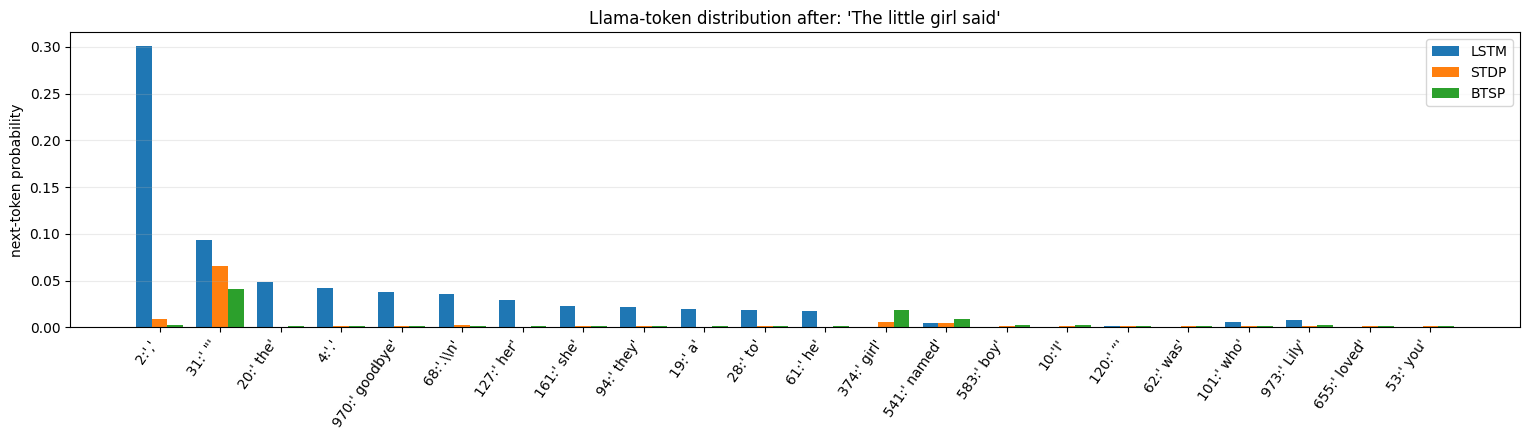

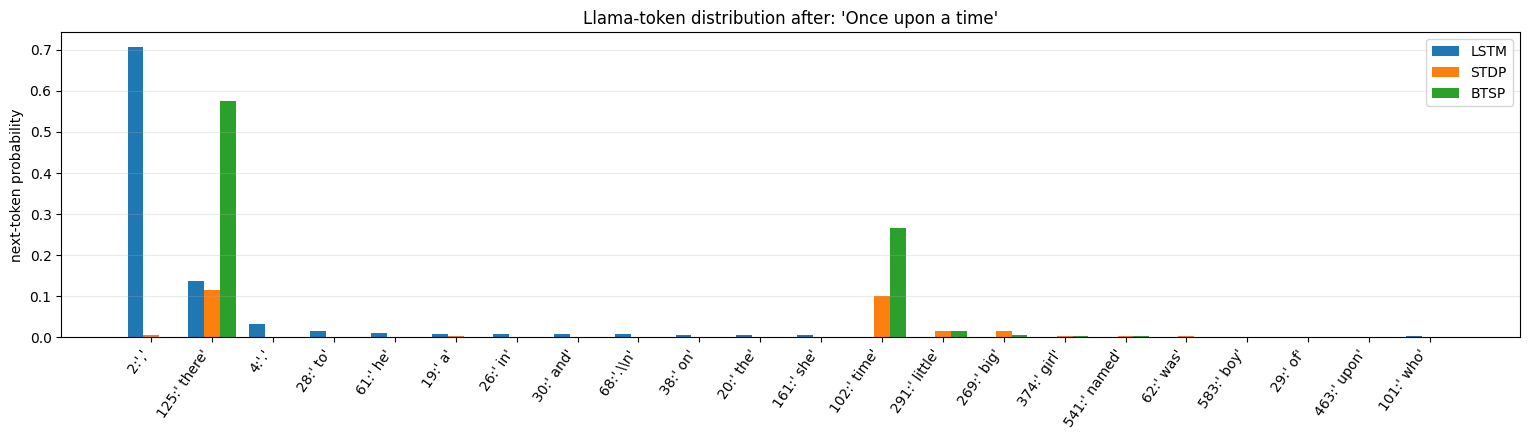

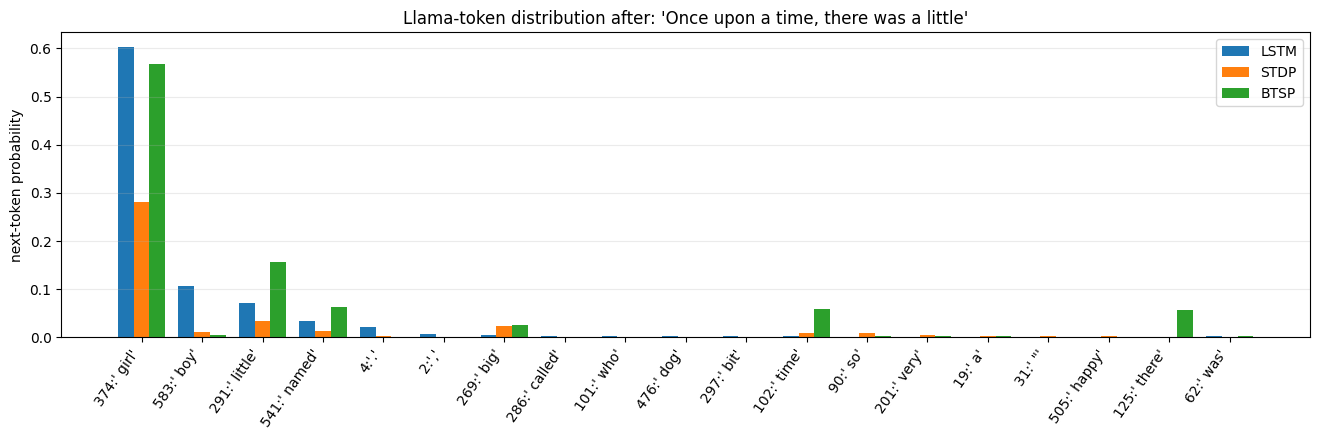

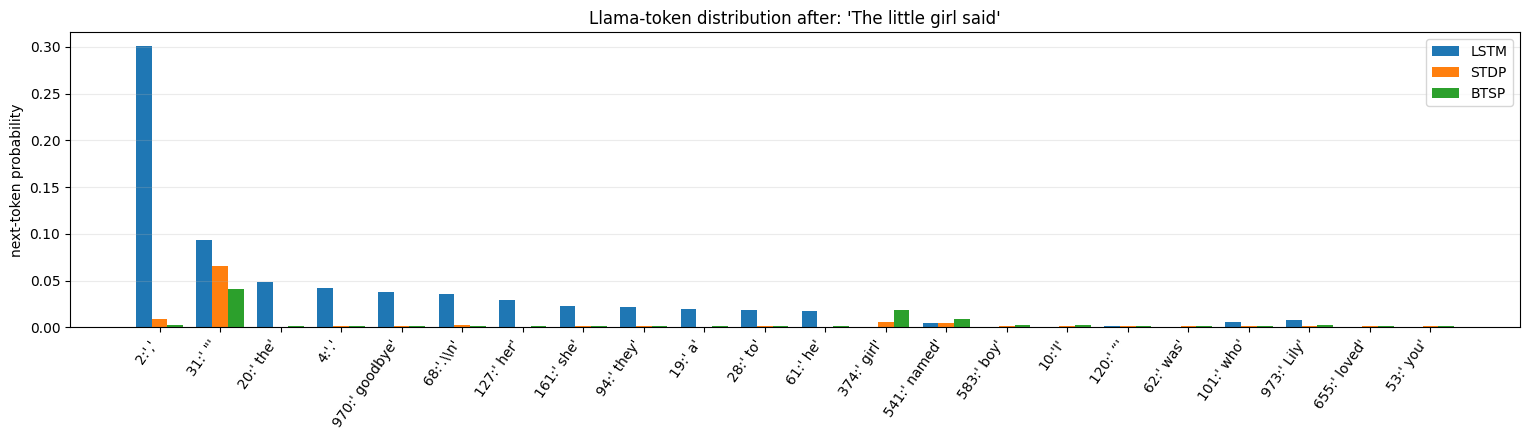

In [9]:
def plot_distributions_for_context(context, k=12):
    probs_by_name = {
        'LSTM': lstm_probs(context),
        'STDP': plastic_probs(context, stdp_w, stdp_decay, plastic_temp),
        'BTSP': plastic_probs(context, btsp_w, btsp_decay, plastic_temp),
    }
    union = []
    for probs in probs_by_name.values():
        for idx in np.argsort(-probs)[:k]:
            if int(idx) not in union:
                union.append(int(idx))
    labels = [token_label(i) for i in union]
    x = np.arange(len(union))
    width = 0.26
    fig, ax = plt.subplots(figsize=(max(12, len(union) * 0.7), 4.5))
    for offset, (name, probs) in zip([-width, 0, width], probs_by_name.items()):
        ax.bar(x + offset, [probs[i] for i in union], width=width, label=name)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=55, ha='right')
    ax.set_ylabel('next-token probability')
    ax.set_title(f'Llama-token distribution after: {context!r}')
    ax.legend()
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    return fig

plot_distributions_for_context('Once upon a time')
plot_distributions_for_context('Once upon a time, there was a little')
plot_distributions_for_context('The little girl said')


## Greedy Continuation

This cell greedily continues English prompts with all three methods: LSTM, STDP and BTSP.

This run was trained on English TinyStories and keeps frequent English-heavy tokens, so the examples below use English prompts.


In [14]:
def step_lstm_token(current, h, c):
    x = params['emb'][current]
    z = params['wx'] @ x + params['wh'] @ h + params['b']
    i = sigmoid(z[:hidden_dim])
    f = sigmoid(z[hidden_dim:2*hidden_dim])
    o = sigmoid(z[2*hidden_dim:3*hidden_dim])
    g = np.tanh(z[3*hidden_dim:])
    c = f * c + i * g
    h = o * np.tanh(c)
    probs = softmax(params['w_out'] @ h + params['b_out'])
    return int(np.argmax(probs)), h, c, probs


def decode_compact(compact_tokens):
    raw_tokens = [compact_to_raw[int(i)] for i in compact_tokens]
    return tokenizer.decode(raw_tokens, skip_special_tokens=True)


def greedy_lstm(prompt, steps=50):
    raw_prompt = tokenizer.encode(prompt, add_special_tokens=False)
    compact_prompt = [raw_to_compact[t] for t in raw_prompt if t in raw_to_compact]
    h = np.zeros(hidden_dim, dtype=np.float32)
    c = np.zeros(hidden_dim, dtype=np.float32)
    if not compact_prompt:
        return '[prompt has no compact-vocab tokens]'
    generated = list(compact_prompt)
    for token in compact_prompt[:-1]:
        _, h, c, _ = step_lstm_token(int(token), h, c)
    current = int(compact_prompt[-1])
    for _ in range(steps):
        current, h, c, _ = step_lstm_token(current, h, c)
        generated.append(current)
    return decode_compact(generated)


def greedy_plastic(prompt, weights, decay, steps=50):
    raw_prompt = tokenizer.encode(prompt, add_special_tokens=False)
    compact_prompt = [raw_to_compact[t] for t in raw_prompt if t in raw_to_compact]
    if not compact_prompt:
        return '[prompt has no compact-vocab tokens]'
    trace = np.zeros(vocab_size, dtype=np.float32)
    generated = list(compact_prompt)
    for token in compact_prompt:
        trace *= decay
        trace[int(token)] += 1.0
    for _ in range(steps):
        scores = weights @ trace
        current = int(np.argmax(scores))
        generated.append(current)
        trace *= decay
        trace[current] += 1.0
    return decode_compact(generated)


for prompt in ['Once upon a time', 'The little girl', 'Tom and Lily went to the']:
    print('PROMPT:', repr(prompt))
    raw_prompt = tokenizer.encode(prompt, add_special_tokens=False)
    print('raw prompt tokens:', [tokenizer.decode([t]) for t in raw_prompt])
    print('kept:', [t in raw_to_compact for t in raw_prompt])
    print('LSTM greedy:')
    print(greedy_lstm(prompt, steps=60))
    print('STDP greedy:')
    print(greedy_plastic(prompt, stdp_w, stdp_decay, steps=60))
    print('BTSP greedy:')
    print(greedy_plastic(prompt, btsp_w, btsp_decay, steps=60))
    print("------------------------------")


PROMPT: 'Once upon a time'
raw prompt tokens: ['Once', ' upon', ' a', ' time']
kept: [True, True, True, True]
LSTM greedy:
Once upon a time, there was a little girl named Lily. She loved to play with the park. She was so proud of the park. She was so proud of the park, and the was so happy, he saw a big. She was so happy, he saw a big. She was so happy, he
STDP greedy:
Once upon a time there was so happy happy happy that she had a big big big big tree tree. She She She She was so happy happy that she had a big big big big tree tree. She She She She was so happy happy that she had a big big big big tree tree. She She She She was
BTSP greedy:
Once upon a time there there there little girl named named named named loved loved loved loved play with with her her her mom her mom mom her mom mom her mom mom her mom mom said " "IIII you you you can can you can."
."
 have."
Lilyilyilyilyilyily Ben Ben said
------------------------------
PROMPT: 'The little girl'
raw prompt tokens: ['The', ' litt

## Why STDP/BTSP Still Lose at Token-Level Next Prediction

The token-level setup fixes the tokenizer issue, but the structural mismatch remains:

- STDP/BTSP are linear association memories over a decayed token trace.
- LSTM maps ordered token sequences into a nonlinear hidden state.
- Cross entropy training teaches the LSTM which token distinctions matter for prediction.
- Plasticity matrices do not receive a corrective signal when they put probability mass on plausible-but-wrong high-frequency tokens.


In [13]:
valid_path = Path(config['valid_file'])
valid_text = valid_path.read_text(encoding='utf-8', errors='replace')[:int(config['valid_chars'])]
valid_raw = tokenizer.encode(valid_text, add_special_tokens=False)
valid_compact = [raw_to_compact[t] for t in valid_raw if t in raw_to_compact]

def context_from_compact_window(end_idx, window=12):
    compact_context = valid_compact[max(0, end_idx-window):end_idx]
    raw_context = [compact_to_raw[i] for i in compact_context]
    return tokenizer.decode(raw_context)

def score_context(context, target_compact):
    rows = []
    for name, probs in [
        ('LSTM', lstm_probs(context)),
        ('STDP', plastic_probs(context, stdp_w, stdp_decay, plastic_temp)),
        ('BTSP', plastic_probs(context, btsp_w, btsp_decay, plastic_temp)),
    ]:
        order = np.argsort(-probs)
        rows.append({
            'method': name,
            'target': token_label(target_compact),
            'p_target': float(probs[target_compact]),
            'rank_target': int(np.where(order == target_compact)[0][0]) + 1,
            'top': token_label(int(order[0])),
            'p_top': float(probs[order[0]]),
            'entropy': entropy(probs),
        })
    return pd.DataFrame(rows)

for end_idx in [50, 120, 240, 500, 900, 1300]:
    context = context_from_compact_window(end_idx, 12)
    target = int(valid_compact[end_idx])
    print('\nCONTEXT:', repr(context))
    display(score_context(context, target))



CONTEXT: ' playing with the car, and Spot felt. They found a'


,method,target,p_target,rank_target,top,p_top,entropy
0,LSTM,288:' small',0.011469,12,269:' big',0.182254,4.996489
1,STDP,288:' small',0.001722,23,269:' big',0.083282,5.954004
2,BTSP,288:' small',0.000374,92,266:' They',0.263333,3.421048



CONTEXT: ' day, found an hill. She had never seen anything like'


,method,target,p_target,rank_target,top,p_top,entropy
0,LSTM,45:' it',0.026991,7,20:' the',0.158548,4.356488
1,STDP,45:' it',0.001487,10,153:' He',0.002702,6.926000
2,BTSP,45:' it',0.003780,12,307:' She',0.024128,6.658618



CONTEXT: ' They will help you climb the hill." and Billy looked for'


...

,method,target,p_target,rank_target,top,p_top,entropy
0,LSTM,901:' ate',0.001641,97,117:' had',0.069764,5.300167
1,STDP,901:' ate',0.000940,412,118:' were',0.003399,6.918609
2,BTSP,901:' ate',0.000698,526,127:' her',0.008811,6.702760



CONTEXT: ' very sad.\nLucy did not give up. She the'


,method,target,p_target,rank_target,top,p_top,entropy
0,LSTM,498:' park',0.011070,14,30:' and',0.062267,5.712261
1,STDP,498:' park',0.003366,9,307:' She',0.207632,4.046863
2,BTSP,498:' park',0.000802,37,307:' She',0.321264,2.329435



CONTEXT: ' and run in the park with his friends.\nOne day,'


,method,target,p_target,rank_target,top,p_top,entropy
0,LSTM,559:' Max',0.003696,37,20:' the',0.100752,4.132989
1,STDP,559:' Max',0.000495,107,"31:' ""'",0.414767,4.253990
2,BTSP,559:' Max',0.000328,198,"31:' ""'",0.486559,3.583607
